In [1]:
from google.colab import files
uploaded = files.upload()


Saving B0005.mat to B0005.mat


In [3]:
import scipy.io as sio

data = sio.loadmat("B0005.mat")
battery = data['B0005']


In [5]:
cycles = battery['cycle'][0,0][0]
len(cycles)



616

In [6]:
discharge_cycles = []

for cycle in cycles:
    if cycle['type'][0] == 'discharge':
        discharge_cycles.append(cycle)


In [7]:
len(discharge_cycles)


168

In [12]:
capacities = []
cycle_nums = []

for cycle in discharge_cycles:
    # The error 'AttributeError: 'numpy.void' object has no attribute 'keys'' indicates that 'cycle' is a numpy.void object.
    # To inspect its fields (analogous to dictionary keys), we use .dtype.names.
    print(f"Inspecting cycle object. Available fields: {cycle.dtype.names}")

    # This line caused the error and has been commented out for now:
    # cycle_num = cycle['cycle'][0][0]

    # Assigning a placeholder to allow execution for inspection.
    # Replace '-1' with the correct cycle number access after identifying the key (e.g., cycle['cycle_index'][0][0]).
    cycle_num = -1

    qd = cycle['data'][0][0]['Qd'][0]
    capacities.append(qd[-1])
    cycle_nums.append(cycle_num)

Inspecting cycle object. Available fields: ('type', 'ambient_temperature', 'time', 'data')


ValueError: no field of name Qd

In [13]:
example_cycle = cycles[0]
example_cycle.dtype.names


('type', 'ambient_temperature', 'time', 'data')

In [14]:
example_cycle['type'][0]


np.str_('charge')

In [15]:
discharge_cycles = []

for cycle in cycles:
    ctype = str(cycle['type'][0]).lower().strip()
    if ctype == "discharge":
        discharge_cycles.append(cycle)

len(discharge_cycles)


168

In [16]:
first_discharge = discharge_cycles[0]
first_discharge.dtype.names


('type', 'ambient_temperature', 'time', 'data')

In [17]:
first_discharge['data'][0][0].dtype.names


('Voltage_measured',
 'Current_measured',
 'Temperature_measured',
 'Current_load',
 'Voltage_load',
 'Time',
 'Capacity')

In [18]:
Qd = first_discharge['data'][0][0]['Qd'][0]
Qd[-1]


ValueError: no field of name Qd

In [19]:
first_discharge = discharge_cycles[0]
first_discharge['data'][0][0].dtype.names


('Voltage_measured',
 'Current_measured',
 'Temperature_measured',
 'Current_load',
 'Voltage_load',
 'Time',
 'Capacity')

In [20]:
Qd = first_discharge['data'][0][0]['Capacity'][0]
Qd[-1]


np.float64(1.8564874208181574)

In [29]:
# cycle['data'] is usually a nested array
cap_vec = cycle['data'][0][0]['Capacity']  # check structure
print(cap_vec.shape)


(1, 1)


In [30]:
capacities = []

for i, cycle in enumerate(discharge_cycles):
    # Sometimes cycle number is just the index + 1
    cycle_num = i + 1

    # Extract capacity vector
    cap_vec = cycle['data'][0][0]['Capacity'][0]

    # Store last value of capacity for this cycle
    capacities.append(cap_vec[-1])

print(capacities)


[np.float64(1.8564874208181574), np.float64(1.846327249719927), np.float64(1.8353491942234077), np.float64(1.8352625275821128), np.float64(1.8346455082120419), np.float64(1.8356616600675495), np.float64(1.8351461429226603), np.float64(1.8257567905665537), np.float64(1.8247738529891333), np.float64(1.824613268496936), np.float64(1.8246195526864504), np.float64(1.8142019357673917), np.float64(1.8137521577549054), np.float64(1.8134404914735822), np.float64(1.8025980036306504), np.float64(1.80210690024615), np.float64(1.802579500826209), np.float64(1.8030683142834096), np.float64(1.8027776247196041), np.float64(1.8470259949329193), np.float64(1.847417311283644), np.float64(1.8361774213478947), np.float64(1.8257807475776242), np.float64(1.8251136435078368), np.float64(1.8255815042203762), np.float64(1.8140311275083907), np.float64(1.8147691941158939), np.float64(1.813969388710352), np.float64(1.802765665167823), np.float64(1.804077040117352), np.float64(1.8518025516704486), np.float64(1.830

In [32]:
import numpy as np

capacities = np.array(capacities)
initial_capacity = capacities[0]  # first cycle capacity
SOH = capacities / initial_capacity  # normalized to 1


In [33]:
import numpy as np

capacities = np.array(capacities)  # make sure it's a NumPy array
initial_capacity = capacities[0]   # capacity of first cycle
SOH = capacities / initial_capacity  # normalized SOH

print("SOH values:\n", SOH)


SOH values:
 [1.         0.99452721 0.98861386 0.98856718 0.98823482 0.98878217
 0.98850449 0.9834469  0.98291743 0.98283094 0.98283432 0.97722285
 0.97698058 0.9768127  0.97097238 0.97070784 0.97096241 0.97122571
 0.97106913 0.99490359 0.99511437 0.98905999 0.9834598  0.98310046
 0.98335248 0.97713085 0.97752841 0.97709759 0.97106269 0.97176906
 0.99747649 0.98611163 0.98029434 0.97458671 0.97205609 0.96923741
 0.96334789 0.96037443 0.95504752 0.9550497  0.95226722 0.94927391
 0.95212996 0.94946421 0.94357251 0.93825015 0.93514846 0.96613852
 0.9605177  0.95199363 0.94642052 0.94095473 0.93817886 0.93532684
 0.92988603 0.92422201 0.9213816  0.91894751 0.91587533 0.91278823
 0.90757572 0.90195826 0.90200948 0.89616356 0.89363055 0.89085121
 0.88481816 0.88223482 0.87947541 0.87679177 0.87376056 0.86794321
 0.86537788 0.86265827 0.856655   0.85418785 0.85373219 0.85943291
 0.848231   0.84293703 0.84017049 0.84001731 0.83743598 0.83430358
 0.82857367 0.82301353 0.82334264 0.82017648 0.81

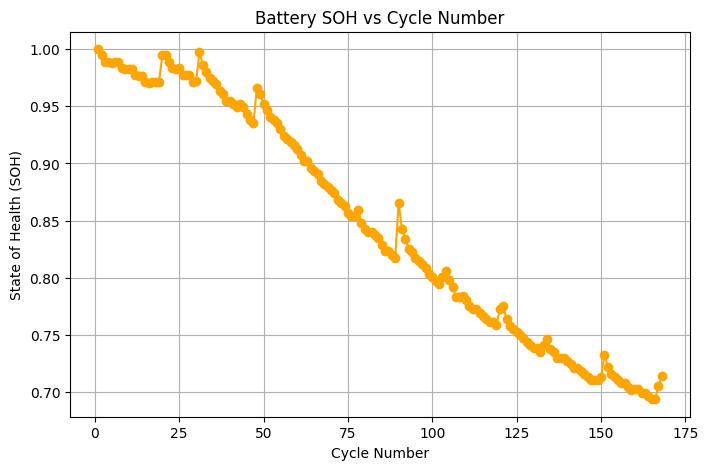

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(SOH)+1), SOH, marker='o', color='orange')
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SOH)')
plt.title('Battery SOH vs Cycle Number')
plt.grid(True)
plt.show()


In [35]:
SOH_threshold = 0.8  # End-of-life threshold


In [36]:
RUL = []

for i, soh in enumerate(SOH):
    remaining_cycles = sum(SOH[i:] > SOH_threshold)
    RUL.append(remaining_cycles)

RUL = np.array(RUL)


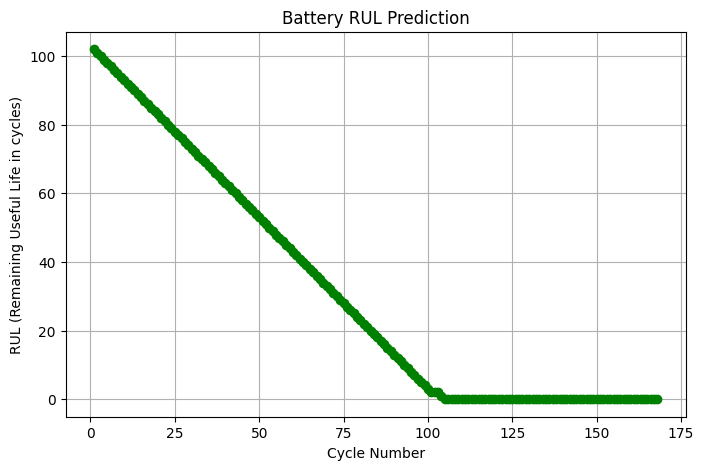

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(RUL)+1), RUL, marker='o', color='green')
plt.xlabel('Cycle Number')
plt.ylabel('RUL (Remaining Useful Life in cycles)')
plt.title('Battery RUL Prediction')
plt.grid(True)
plt.show()


In [38]:
import numpy as np
import pandas as pd

# Assume SOH and RUL are numpy arrays
SOH = np.array(SOH)
RUL = np.array(RUL)

window_size = 5  # number of previous cycles to consider
X = []
y = []

for i in range(len(SOH) - window_size):
    X.append(SOH[i:i+window_size])  # take window of SOH
    y.append(RUL[i+window_size])    # RUL after that window

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)


Feature shape: (163, 5)
Label shape: (163,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test R2 Score:", r2)


Test MSE: 45.03343636363639
Test R2 Score: 0.9595449997772729


In [41]:
last_window = SOH[-window_size:]  # last few cycles
predicted_RUL = model.predict([last_window])[0]
print(f"Predicted RUL for the current battery state: {predicted_RUL:.2f} cycles")


Predicted RUL for the current battery state: 0.00 cycles


In [42]:
import numpy as np
from numpy import polyfit

cycles = np.arange(1, len(SOH)+1)
# Fit linear or exponential decay
coeffs = polyfit(cycles, SOH, 1)  # linear
m, b = coeffs
SOH_threshold = 0.8
predicted_EOL_cycle = (SOH_threshold - b) / m
predicted_RUL = predicted_EOL_cycle - len(SOH)

print(f"Predicted RUL: {predicted_RUL:.2f} cycles")


Predicted RUL: -60.92 cycles


In [43]:
predicted_RUL = max(predicted_RUL, 0)
print(f"Predicted RUL: {predicted_RUL:.2f} cycles")


Predicted RUL: 0.00 cycles


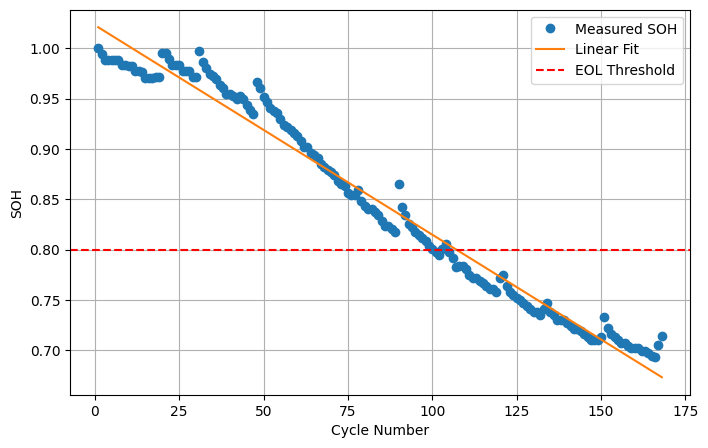

In [44]:
import matplotlib.pyplot as plt
import numpy as np

cycles = np.arange(1, len(SOH)+1)
m, b = np.polyfit(cycles, SOH, 1)

# Predicted SOH line
fitted_line = m*cycles + b

plt.figure(figsize=(8,5))
plt.plot(cycles, SOH, 'o', label='Measured SOH')
plt.plot(cycles, fitted_line, '-', label='Linear Fit')
plt.axhline(y=SOH_threshold, color='r', linestyle='--', label='EOL Threshold')
plt.xlabel('Cycle Number')
plt.ylabel('SOH')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
# Polynomial fit (2nd degree)
coeffs = np.polyfit(cycles, SOH, 2)
poly_SO = np.poly1d(coeffs)

# Solve for EOL
from scipy.optimize import fsolve
EOL_cycle = fsolve(lambda x: poly_SO(x) - SOH_threshold, len(SOH))[0]
predicted_RUL = max(EOL_cycle - len(SOH), 0)
print(f"Predicted RUL (poly fit): {predicted_RUL:.2f} cycles")


Predicted RUL (poly fit): 0.00 cycles


In [46]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# cycles, SOH, RUL arrays are already available
cycles = np.arange(1, len(SOH)+1)

def plot_degradation(max_cycle):
    plt.figure(figsize=(8,5))
    plt.plot(cycles[:max_cycle], SOH[:max_cycle], marker='o', color='orange', label='SOH')
    plt.plot(cycles[:max_cycle], RUL[:max_cycle], marker='x', color='green', label='RUL')
    plt.xlabel('Cycle Number')
    plt.ylabel('Value')
    plt.title('Battery Cycle Degradation Trend')
    plt.legend()
    plt.grid(True)
    plt.show()

# Interactive slider
slider = widgets.IntSlider(value=len(cycles), min=1, max=len(cycles), step=1, description='Cycle')
widgets.interact(plot_degradation, max_cycle=slider)


interactive(children=(IntSlider(value=168, description='Cycle', max=168, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_degradation(max_cycle)>